In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

import import_ipynb
# import os
# cur_path = os.getcwd()
# os.chdir('path_to_Judd_Ofeld_Base')
from Judd_Ofeld_Base import JuddOfeltAnalyzer
# os.chdir(cur_path)

In [2]:
path_to_Nd_results = Path('./0.5_Abs_Pristine_PZ_Nd_Omega_[4.03, 3.35, 3.36]_rel_AUC_400_800.pkl')

In [3]:
# Загрузка результатов расчета параметров J-O (Judd_Ofelt.result_df)
# Предполагается, что данные уже предобработаны и содержат нужные колонки

df_pristine_Nd = pd.read_pickle(path_to_Nd_results)
# df_reference_Nd = pd.read_pickle(path_to_reference_results)


In [4]:
analyzer = JuddOfeltAnalyzer(
    df=df_pristine_Nd,
    ion="Nd3+",
    name="Pristine_PZ_Nd_0.5"
)

print(f"Группы: {analyzer.unique_groups}")
print(f"Образец: {analyzer.name}")

Группы: [0 1 2 3 4]
Образец: Pristine_PZ_Nd_0.5


In [5]:
# Если есть референсный (pristine) спектр и результаты его обработки.
# noise = analyzer.estimate_noise(reference_df=df_reference_Nd)
# print("Оценённый шум по группам:", np.round(noise, 4))

In [6]:
initial_omegas = np.array([3., 5., 3.5])   # стартовое приближение

omegas_fitted = analyzer.fit(
    initial_omegas=initial_omegas,
    target='AUC',      # или 'LS'
    loss='abs',        # или 'rel'
    noise=0.05,       # можно передать None, если шум не учитываем
    noise_scale=0.75,  # коэффициент масштаба шума
)

print("Подогнанные параметры Ω:")
print(f"Ω2 = {omegas_fitted[0]:.4f}")
print(f"Ω4 = {omegas_fitted[1]:.4f}")
print(f"Ω6 = {omegas_fitted[2]:.4f}")

Подогнанные параметры Ω:
Ω2 = 4.2346
Ω4 = 3.2574
Ω6 = 3.4044


In [7]:
# noise как Разница средних площадей по группам
noise = np.array([0.0714,0.5803,0.96773333,0.26175,1.70475])
bts_results = analyzer.bootstrap(
    n_samples=50,
    initial_omegas=initial_omegas,
    target='AUC',
    loss='abs',
    noise=noise,
    noise_scale=0.75,
    random_state=42
)

print("\nСтатистика bootstrap:")
print(bts_results.describe().round(4))

Bootstrap Pristine_PZ_Nd_0.5:   0%|          | 0/50 [00:00<?, ?it/s]


Статистика bootstrap:
        Omega2   Omega4   Omega6
count  50.0000  50.0000  50.0000
mean    4.0480   3.3850   3.3443
std     0.2183   0.3634   0.1368
min     3.5520   2.5428   3.0544
25%     3.9288   3.1386   3.2325
50%     4.0233   3.4227   3.3426
75%     4.1973   3.6047   3.4264
max     4.5319   4.2172   3.7803


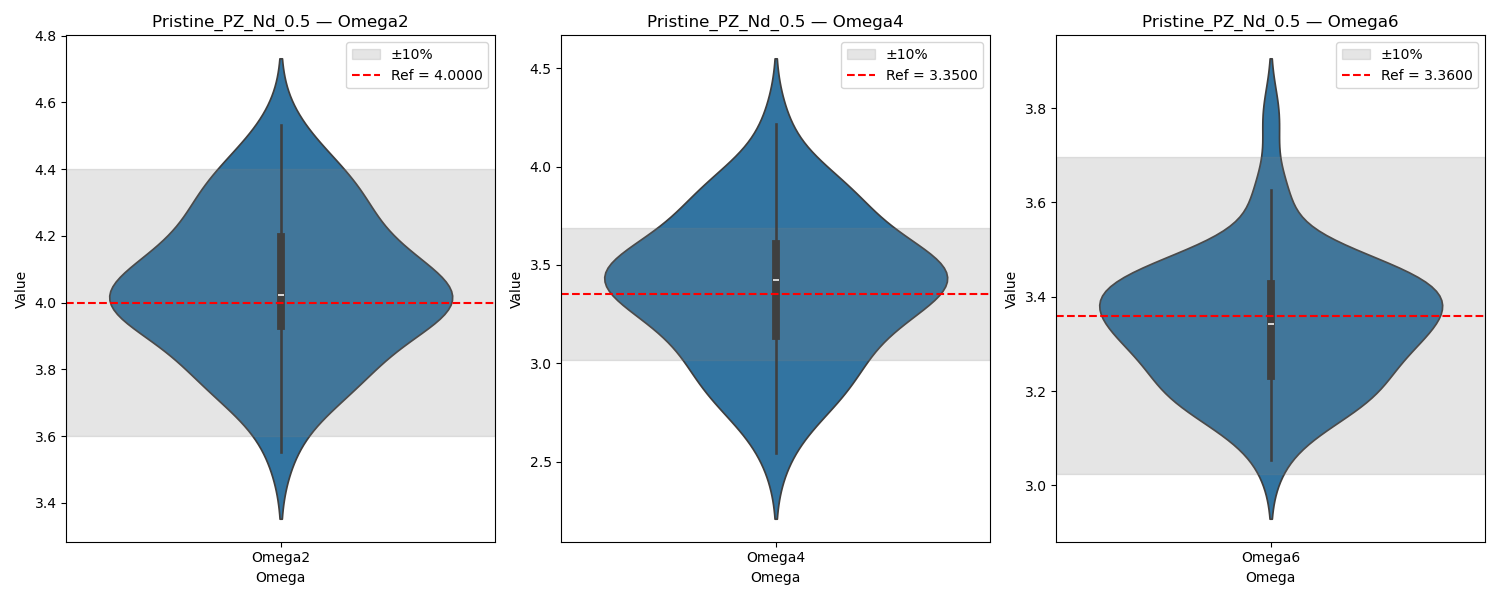

In [8]:
reference_values = {'Omega2': 4.0, 'Omega4': 3.35, 'Omega6': 3.36}
analyzer.plot_omega_distributions(
    bootstrap_df=bts_results,
    reference=reference_values
)

In [9]:
loo_bts_results = analyzer.loo_bootstrap(
        n_samples=10,
        initial_omegas=initial_omegas,
        target='AUC',
        loss='abs',
        noise=noise,
        noise_scale=0.75,
        random_state=42
)

print("\nСтатистика bootstrap:")
print(loo_bts_results.describe().round(4))

LOO Bootstrap Pristine_PZ_Nd_0.5:   0%|          | 0/5 [00:00<?, ?it/s]

  Group 0 excluded:   0%|          | 0/10 [00:00<?, ?it/s]

  Group 1 excluded:   0%|          | 0/10 [00:00<?, ?it/s]

  Group 2 excluded:   0%|          | 0/10 [00:00<?, ?it/s]

  Group 3 excluded:   0%|          | 0/10 [00:00<?, ?it/s]

  Group 4 excluded:   0%|          | 0/10 [00:00<?, ?it/s]


Статистика bootstrap:
        Omega2   Omega4   Omega6
count  50.0000  50.0000  50.0000
mean    2.8994   4.2626   2.6421
std     1.5915   1.0868   1.3404
min     0.0000   2.3857   0.0000
25%     2.5257   3.3159   3.1223
50%     3.5089   4.3334   3.2351
75%     4.0937   5.0039   3.3763
max     4.6566   6.9381   3.5717


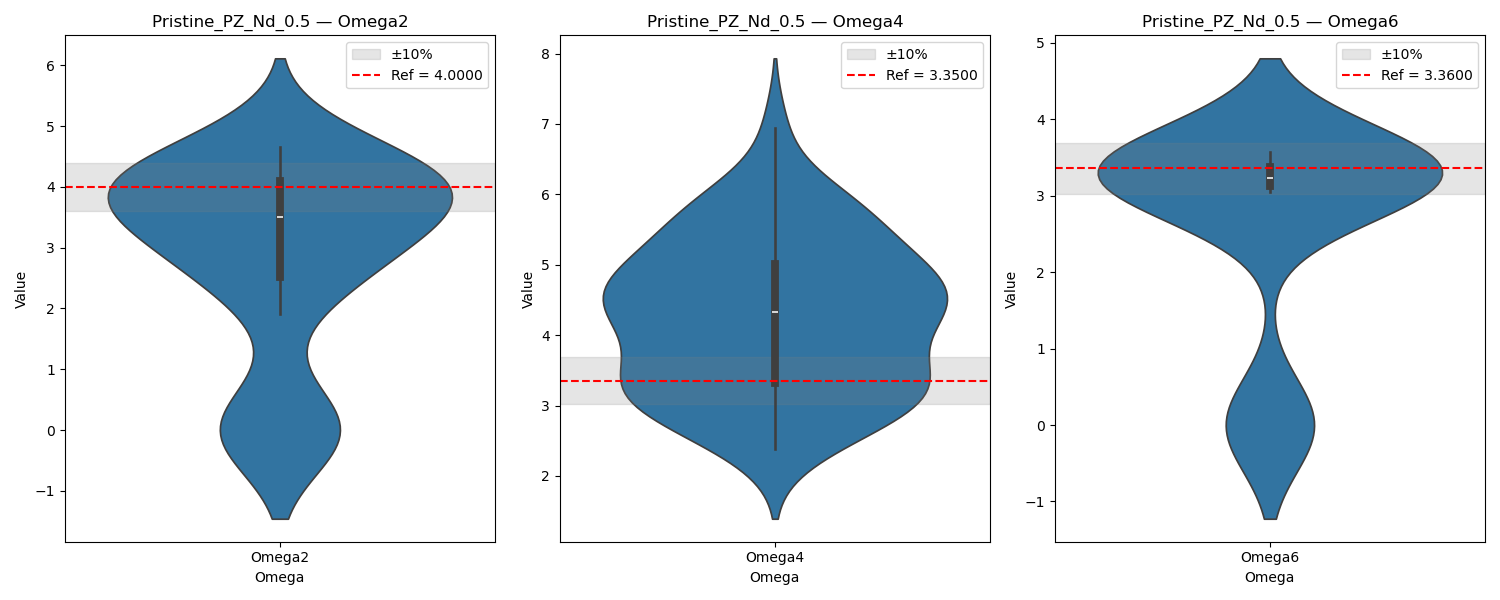

In [10]:
analyzer.plot_omega_distributions(
    bootstrap_df=loo_bts_results,
    reference=reference_values
)

In [11]:
det_tb,summ = analyzer.get_results(
                    omegas=omegas_fitted,
                    target='AUC'
                )
print(summ)
det_tb

{'name': 'Pristine_PZ_Nd_0.5', 'ion': 'Nd3+', 'omegas': [4.2345940482, 3.2574315294, 3.4043771449], 'rmse': np.float64(3.44906), 'n_groups': 5, 'target': 'AUC'}


,Group,Exp,Calc,Diff,Rel_Diff_%
0,0,0.9053,1.2931,-0.3878,-42.84
1,1,3.7823,0.7232,3.0591,80.88
2,2,12.0222,12.2731,-0.2509,-2.09
3,3,82.6333,84.0836,-1.4503,-1.76
4,4,41.1534,41.6237,-0.4703,-1.14
